# TP53 Mutation Prediction — Main Results Notebook

This notebook verifies the training pipeline and compares results across both datasets:
- **CCLE** — cancer cell lines (~1,700 samples)
- **TCGA** — primary tumours (~9,700 samples)

Training is run separately in `0_tcga_00_pipeline.ipynb`. Run that first, then use this notebook to inspect and compare results.

## Step 0: Setup

In [2]:
from __future__ import annotations
import sys, math
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tp53_ml.config import load_config

cfg = load_config('../config/project.yaml')
TEST_SIZE   = cfg['split']['test_size']
VAL_SIZE    = cfg['split']['validation_size']
MIN_STRATUM = math.ceil(1 / min(TEST_SIZE, VAL_SIZE))

print(f'Test size: {TEST_SIZE},  Val size: {VAL_SIZE}')
print(f'Min stratum count (per cancer type): {MIN_STRATUM}')

Test size: 0.15,  Val size: 0.15
Min stratum count (per cancer type): 7


## Step 1: Cancer Type Filtering — Verification

Before splitting, the training script removes cancer types with fewer than `MIN_STRATUM` samples. The motivation: if a cancer type has very few samples, the model may learn to predict TP53 status by recognising the lineage rather than reading the expression signature (TP53 mutation rates vary heavily by cancer type).

Here we show exactly which types were dropped for each dataset.

In [3]:
def load_disease_counts(labels_path, meta_path):
    labels = pd.read_csv(labels_path)
    meta   = pd.read_csv(meta_path)
    if 'primary_disease' not in meta.columns:
        for col in meta.columns:
            if col.lower().replace('_', '') in ('oncotreeprimarydisease', 'primarydisease'):
                meta = meta.rename(columns={col: 'primary_disease'})
                break
        else:
            meta['primary_disease'] = 'Unknown'
    merged = labels[['sample_id']].merge(meta[['sample_id', 'primary_disease']], on='sample_id', how='left')
    counts = merged['primary_disease'].value_counts().reset_index()
    counts.columns = ['primary_disease', 'n_samples']
    counts['retained'] = counts['n_samples'] >= MIN_STRATUM
    return counts

ccle_counts = load_disease_counts('../data/processed/tp53_labels.csv',
                                   '../data/processed/sample_metadata.csv')
tcga_counts = load_disease_counts('../data/processed/tcga/tp53_labels.csv',
                                   '../data/processed/tcga/sample_metadata.csv')

for name, counts in [('CCLE', ccle_counts), ('TCGA', tcga_counts)]:
    print(f'=== {name} ===')
    print(f"  Total cancer types : {len(counts)}")
    print(f"  Retained (>= {MIN_STRATUM}) : {counts['retained'].sum()}")
    print(f"  Dropped  (<  {MIN_STRATUM}) : {(~counts['retained']).sum()}")
    print()

=== CCLE ===
  Total cancer types : 93
  Retained (>= 7) : 42
  Dropped  (<  7) : 51

=== TCGA ===
  Total cancer types : 32
  Retained (>= 7) : 32
  Dropped  (<  7) : 0



In [4]:
print('=== CCLE — dropped cancer types ===')
dropped_ccle = ccle_counts[~ccle_counts['retained']]
print(dropped_ccle.to_string(index=False) if len(dropped_ccle) else '  None dropped.')
print()
print('=== TCGA — dropped cancer types ===')
dropped_tcga = tcga_counts[~tcga_counts['retained']]
print(dropped_tcga.to_string(index=False) if len(dropped_tcga) else '  None dropped.')

=== CCLE — dropped cancer types ===
                                              primary_disease  n_samples  retained
                          Intracholecystic Papillary Neoplasm          6     False
                                      Prostate Adenocarcinoma          6     False
                                                 Wilms' Tumor          5     False
                                          Ampullary Carcinoma          5     False
                            Cutaneous Squamous Cell Carcinoma          5     False
                                               Chondrosarcoma          5     False
                                      Cervical Adenocarcinoma          5     False
                                  Uterine Sarcoma/Mesenchymal          4     False
                              Breast Ductal Carcinoma In Situ          4     False
                     SMARCA4-deficient undifferentiated tumor          4     False
                                        Merkel Cell

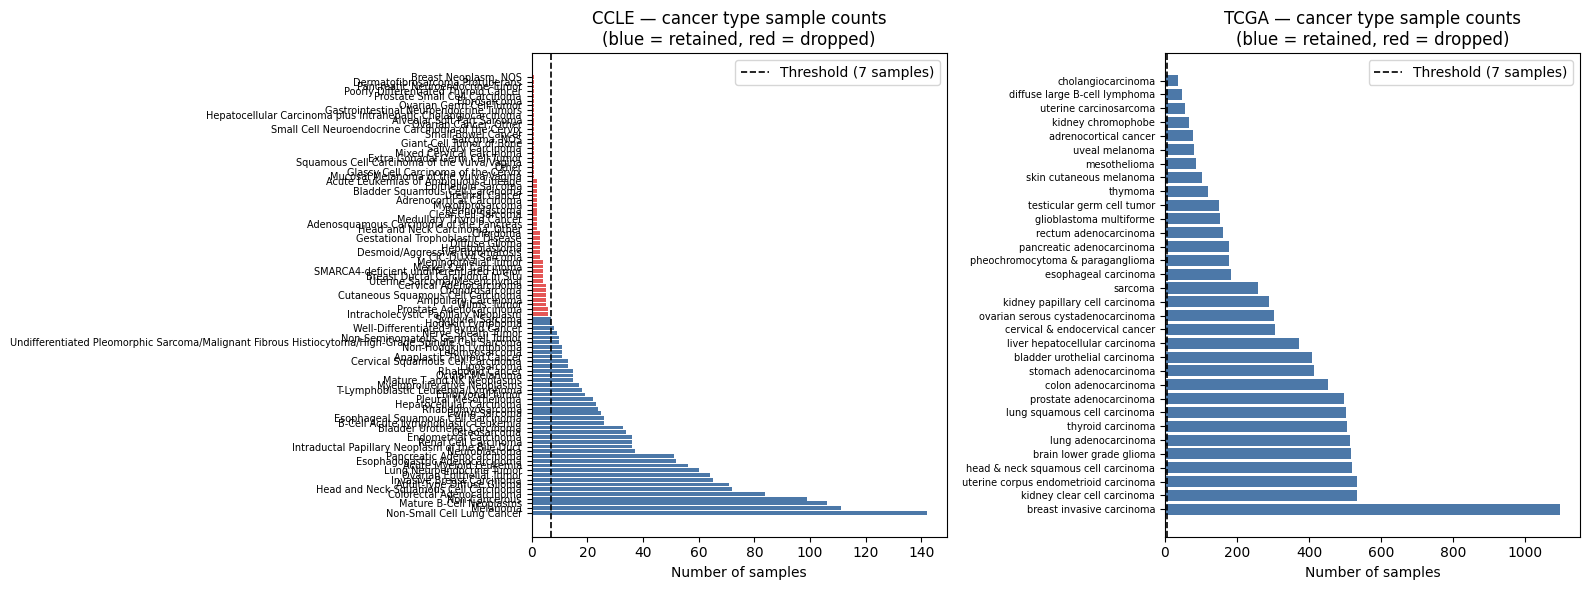

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, counts, title in zip(axes, [ccle_counts, tcga_counts], ['CCLE', 'TCGA']):
    colors = counts['retained'].map({True: '#4C78A8', False: '#E45756'})
    ax.barh(counts['primary_disease'], counts['n_samples'], color=colors)
    ax.axvline(MIN_STRATUM, color='black', linestyle='--', linewidth=1.2,
               label=f'Threshold ({MIN_STRATUM} samples)')
    ax.set_xlabel('Number of samples')
    ax.set_title(f'{title} — cancer type sample counts\n(blue = retained, red = dropped)')
    ax.legend()
    ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('../reports/figures/cancer_type_filter_verification.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2: Hyperparameter Tuning — Verification

The multiclass script runs a coordinate hill-climb on the validation set (up to 3 rounds, optimising macro-F1). Here we compare the untuned baseline against the tuned results for both CCLE and TCGA (no-splice).

In [6]:
def load_tuning_comparison(baseline_path, tuned_path, label):
    base  = pd.read_csv(baseline_path)
    tuned = pd.read_csv(tuned_path)
    merged = base[['feature_set', 'model', 'macro_f1']].merge(
        tuned[['feature_set', 'model', 'macro_f1', 'best_params']],
        on=['feature_set', 'model'],
        suffixes=('_baseline', '_tuned')
    )
    merged['delta_f1'] = merged['macro_f1_tuned'] - merged['macro_f1_baseline']
    merged['dataset']  = label
    return merged.sort_values('macro_f1_tuned', ascending=False)

ccle_cmp = load_tuning_comparison(
    '../reports/tables/ccle_multiclass_validation_performance.csv',
    '../reports/tables/ccle_multiclass_tuned_validation_performance.csv',
    'CCLE'
)
tcga_ns_cmp = load_tuning_comparison(
    '../reports/tables/tcga_nosplice_multiclass_validation_performance.csv',
    '../reports/tables/tcga_nosplice_multiclass_tuned_validation_performance.csv',
    'TCGA (no-splice)'
)

print('=== CCLE — top 5 tuned models (validation) ===')
print(ccle_cmp[['feature_set', 'model', 'macro_f1_baseline', 'macro_f1_tuned', 'delta_f1', 'best_params']].head(5).to_string(index=False))
print()
print('=== TCGA no-splice — top 5 tuned models (validation) ===')
print(tcga_ns_cmp[['feature_set', 'model', 'macro_f1_baseline', 'macro_f1_tuned', 'delta_f1', 'best_params']].head(5).to_string(index=False))

=== CCLE — top 5 tuned models (validation) ===
 feature_set                  model  macro_f1_baseline  macro_f1_tuned  delta_f1                                                               best_params
 p53_pathway                    mlp           0.381916        0.508348  0.126432          alpha=0.001; hidden_layer_sizes=(128,); learning_rate_init=0.003
 p53_pathway            extra_trees           0.313367        0.456985  0.143619   max_depth=16; max_features='sqrt'; min_samples_leaf=5; n_estimators=500
 p53_pathway          random_forest           0.383935        0.447208  0.063273  max_depth=None; max_features=0.25; min_samples_leaf=10; n_estimators=400
tp53_targets hist_gradient_boosting           0.417806        0.433387  0.015581 l2_regularization=0.1; learning_rate=0.1; max_iter=150; max_leaf_nodes=31
tp53_targets            extra_trees           0.357540        0.421854  0.064314   max_depth=None; max_features=0.25; min_samples_leaf=1; n_estimators=500

=== TCGA no-splice — t

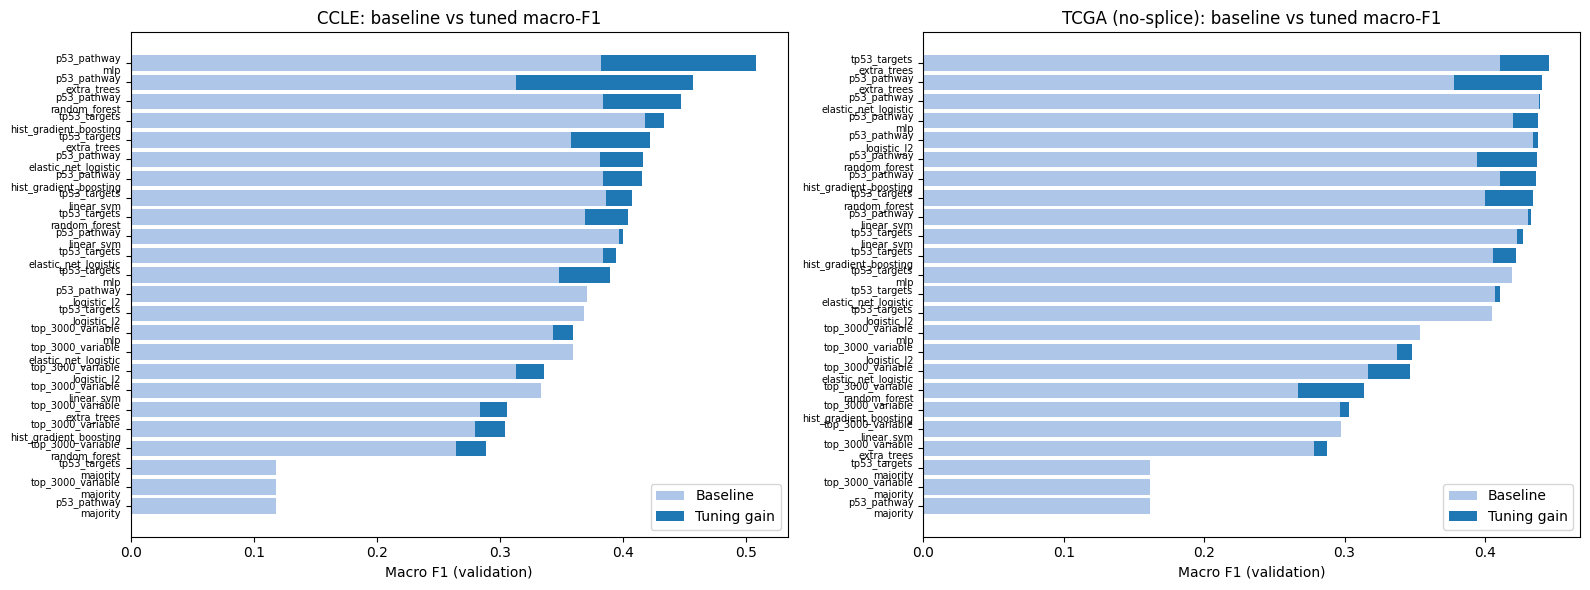

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, cmp_df, title in zip(axes,
                              [ccle_cmp, tcga_ns_cmp],
                              ['CCLE', 'TCGA (no-splice)']):
    plot_df = cmp_df.sort_values('macro_f1_tuned', ascending=True).copy()
    plot_df['combo'] = plot_df['feature_set'] + '\n' + plot_df['model']
    y = range(len(plot_df))
    ax.barh(list(y), plot_df['macro_f1_baseline'], color='#aec7e8', label='Baseline')
    ax.barh(list(y), plot_df['macro_f1_tuned'] - plot_df['macro_f1_baseline'],
            left=plot_df['macro_f1_baseline'], color='#1f77b4', label='Tuning gain')
    ax.set_yticks(list(y))
    ax.set_yticklabels(plot_df['combo'], fontsize=7)
    ax.set_xlabel('Macro F1 (validation)')
    ax.set_title(f'{title}: baseline vs tuned macro-F1')
    ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/tuning_gain_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3: Cross-Dataset Results Comparison

Best model per dataset and task on the held-out test set.

In [8]:
# Binary — these were run separately (03_train_binary.py already had filtering + tuning)
ccle_bin = pd.read_csv('../reports/tables/binary_test_performance.csv')
tcga_bin = pd.read_csv('../reports/tables/tcga_binary_test_performance.csv')

def bin_entry(label, row):
    return {
        'Dataset':     label,
        'Feature set': row['feature_set'],
        'Model':       row['model'],
        'ROC-AUC':     round(row['roc_auc'], 4),
        'Balanced Acc':round(row['balanced_accuracy'], 4),
        'F1':          round(row['f1'], 4),
    }

binary_summary = pd.DataFrame([
    bin_entry('CCLE', ccle_bin.iloc[0]),
    bin_entry('TCGA', tcga_bin.iloc[0]),
])

print('=== Binary Classification (test set) ===')
binary_summary

=== Binary Classification (test set) ===


,Dataset,Feature set,Model,ROC-AUC,Balanced Acc,F1
0,CCLE,p53_pathway,random_forest,0.9056,0.8119,0.8625
1,TCGA,p53_pathway,random_forest,0.9086,0.8282,0.7818


In [10]:
# Multiclass — all from the new tuned pipeline
ccle_mc    = pd.read_csv('../reports/tables/ccle_multiclass_tuned_test_performance.csv')
tcga_ns_mc = pd.read_csv('../reports/tables/tcga_nosplice_multiclass_tuned_test_performance.csv')

def mc_entry(label, classes, row):
    return {
        'Dataset':     label,
        'Classes':     classes,
        'Feature set': row['feature_set'],
        'Model':       row['model'],
        'Macro F1':    round(row['macro_f1'], 4),
        'Balanced Acc':round(row['balanced_accuracy'], 4),
        'Weighted F1': round(row['weighted_f1'], 4),
    }

CCLE_CLASSES     = 'WT / Missense / Nonsense / Frameshift / Other'
TCGA_NS_CLASSES  = 'WT / Missense / Nonsense / Frameshift / Other'

multiclass_summary = pd.DataFrame([
    mc_entry('CCLE',             CCLE_CLASSES,    ccle_mc.iloc[0]),
    mc_entry('TCGA (no-splice)', TCGA_NS_CLASSES, tcga_ns_mc.iloc[0]),
])

print('=== Multiclass Classification (test set) ===')
multiclass_summary

=== Multiclass Classification (test set) ===


,Dataset,Classes,Feature set,Model,Macro F1,Balanced Acc,Weighted F1
0,CCLE,WT / Missense / Nonsense / Frameshift / Other,p53_pathway,mlp,0.4545,0.4566,0.7157
1,TCGA (no-splice),WT / Missense / Nonsense / Frameshift / Other,tp53_targets,extra_trees,0.4447,0.4746,0.7497


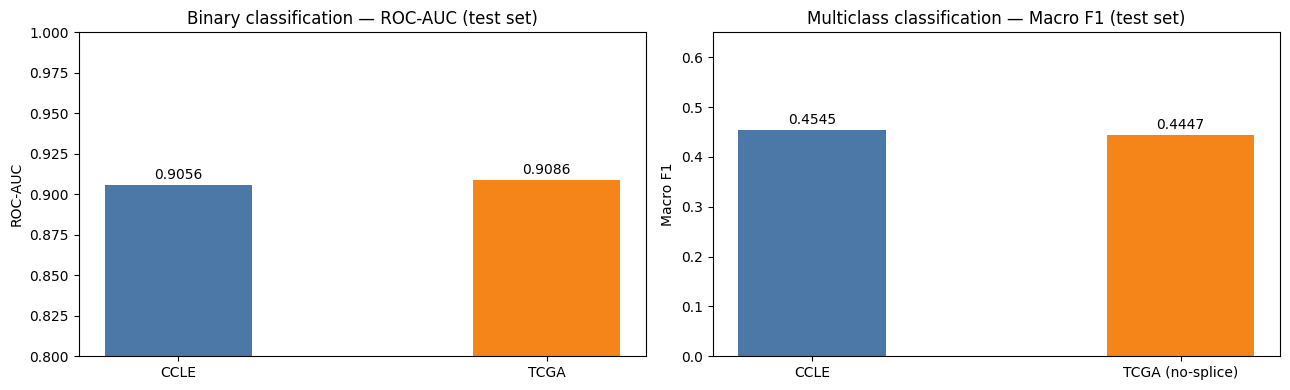

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Binary — ROC-AUC
ax = axes[0]
bars = ax.bar(binary_summary['Dataset'], binary_summary['ROC-AUC'],
              color=['#4C78A8', '#F58518'], width=0.4)
ax.set_ylim(0.8, 1.0)
ax.set_ylabel('ROC-AUC')
ax.set_title('Binary classification — ROC-AUC (test set)')
for bar, val in zip(bars, binary_summary['ROC-AUC']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# Multiclass — Macro F1
ax = axes[1]
bars = ax.bar(multiclass_summary['Dataset'], multiclass_summary['Macro F1'],
              color=['#4C78A8', '#F58518', '#54A24B'], width=0.4)
ax.set_ylim(0, 0.65)
ax.set_ylabel('Macro F1')
ax.set_title('Multiclass classification — Macro F1 (test set)')
for bar, val in zip(bars, multiclass_summary['Macro F1']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print('=== Full Results Summary ===')
print()
print('BINARY')
print(binary_summary.to_string(index=False))
print()
print('MULTICLASS')
print(multiclass_summary.to_string(index=False))

=== Full Results Summary ===

BINARY
Dataset Feature set         Model  ROC-AUC  Balanced Acc     F1
   CCLE p53_pathway random_forest   0.9056        0.8119 0.8625
   TCGA p53_pathway random_forest   0.9086        0.8282 0.7818

MULTICLASS
         Dataset                                       Classes  Feature set       Model  Macro F1  Balanced Acc  Weighted F1
            CCLE WT / Missense / Nonsense / Frameshift / Other  p53_pathway         mlp    0.4545        0.4566       0.7157
TCGA (no-splice) WT / Missense / Nonsense / Frameshift / Other tp53_targets extra_trees    0.4447        0.4746       0.7497


## Step 4: Report

### Project Overview

This project asks whether TP53 mutation status — and mutation type — can be predicted from RNA-seq gene expression profiles. TP53 is the most frequently mutated gene in human cancer (~50% of all tumours). As a transcription factor controlling cell cycle arrest, apoptosis, and DNA repair, TP53 mutations leave a measurable downstream signature in gene expression. We test whether this signature is strong enough for a classifier to learn.

We train and evaluate models on two independent datasets:
- **CCLE** (DepMap 26Q1) — 1,719 cancer cell lines, expression in log2(TPM+1)
- **TCGA** (UCSC Xena pan-cancer atlas) — 9,701 primary tumours, expression in RSEM

Two tasks are evaluated:
1. **Binary** — TP53 mutant vs wild-type
2. **Multiclass** — mutation type (WT / Missense / Nonsense / Frameshift / Other)

---

### Methodology

#### Cancer Type Filtering

Before splitting, cancer types with fewer than **7 samples** are removed from training. The threshold of 7 is derived directly from the split sizes: with a 70/15/15 train/val/test split, the minimum number of samples needed in any stratum to guarantee at least one sample in both the validation and test sets is $\lceil 1 / \min(0.15, 0.15) 
ceil = 7$. Below this threshold, stratified splitting cannot be performed reliably.

Beyond the technical requirement, this filter also serves a biological purpose: TP53 mutation rates vary heavily by cancer type. A model trained on rare cancer types with only a handful of samples could learn to predict TP53 status by memorising lineage identity rather than reading the transcriptional signature — inflating apparent performance without learning anything generalisable.

#### Hyperparameter Tuning

We use a **coordinate hill-climb** on the validation set rather than exhaustive grid search or random search. The algorithm works as follows:

- Start from the model's default hyperparameters
- Each round: for every hyperparameter, evaluate the two neighbouring values in the search grid
- Accept any change that improves the primary metric (ROC-AUC for binary, macro-F1 for multiclass) by at least ^{-4}$
- Stop after 3 rounds or when no improvement is found

This approach was chosen over grid search because the full Cartesian product of parameter combinations across 7 models × 3 feature sets would require thousands of fits on a 9,700-sample dataset — computationally infeasible. The hill-climb explores the neighbourhood of the default parameters efficiently, typically converging in 1–2 rounds, while still capturing meaningful tuning gains for models like logistic regression (where regularisation strength matters significantly) and gradient boosting.

---

### Results


In [13]:
ccle_bin  = pd.read_csv("../reports/tables/binary_test_performance.csv")
tcga_bin  = pd.read_csv("../reports/tables/tcga_binary_test_performance.csv")
ccle_mc   = pd.read_csv("../reports/tables/ccle_multiclass_tuned_test_performance.csv")
tcga_mc   = pd.read_csv("../reports/tables/tcga_nosplice_multiclass_tuned_test_performance.csv")

summary = pd.DataFrame([
    {"Dataset": "CCLE",  "Task": "Binary",     "Model": ccle_bin.iloc[0]["model"],  "Feature set": ccle_bin.iloc[0]["feature_set"],  "Primary metric": f'ROC-AUC {ccle_bin.iloc[0]["roc_auc"]:.3f}',  "Balanced Acc": f'{ccle_bin.iloc[0]["balanced_accuracy"]:.3f}'},
    {"Dataset": "TCGA",  "Task": "Binary",     "Model": tcga_bin.iloc[0]["model"],  "Feature set": tcga_bin.iloc[0]["feature_set"],  "Primary metric": f'ROC-AUC {tcga_bin.iloc[0]["roc_auc"]:.3f}',  "Balanced Acc": f'{tcga_bin.iloc[0]["balanced_accuracy"]:.3f}'},
    {"Dataset": "CCLE",  "Task": "Multiclass", "Model": ccle_mc.iloc[0]["model"],   "Feature set": ccle_mc.iloc[0]["feature_set"],   "Primary metric": f'Macro F1 {ccle_mc.iloc[0]["macro_f1"]:.3f}',   "Balanced Acc": f'{ccle_mc.iloc[0]["balanced_accuracy"]:.3f}'},
    {"Dataset": "TCGA",  "Task": "Multiclass", "Model": tcga_mc.iloc[0]["model"],   "Feature set": tcga_mc.iloc[0]["feature_set"],   "Primary metric": f'Macro F1 {tcga_mc.iloc[0]["macro_f1"]:.3f}',   "Balanced Acc": f'{tcga_mc.iloc[0]["balanced_accuracy"]:.3f}'},
])
summary

,Dataset,Task,Model,Feature set,Primary metric,Balanced Acc
0,CCLE,Binary,random_forest,p53_pathway,ROC-AUC 0.906,0.812
1,TCGA,Binary,random_forest,p53_pathway,ROC-AUC 0.909,0.828
2,CCLE,Multiclass,mlp,p53_pathway,Macro F1 0.455,0.457
3,TCGA,Multiclass,extra_trees,tp53_targets,Macro F1 0.445,0.475


### Discussion

**Binary classification** is strongly solvable on both datasets. ROC-AUC above 0.90 on held-out test data confirms that TP53 mutation status leaves a clear and learnable transcriptional footprint. TCGA outperforms CCLE slightly, likely due to its larger sample size giving models more signal to learn from, despite being noisier (primary tumours vs controlled cell lines).

**Multiclass classification** is fundamentally harder. All TP53 mutation types — Missense, Nonsense, Frameshift — disrupt the same downstream transcriptional programme regardless of mechanism. The cell's response to a frameshift and a nonsense mutation is nearly identical at the RNA level, leaving very little signal to distinguish classes. Macro F1 in the 0.35–0.47 range represents the practical ceiling for this task on bulk RNA-seq data, regardless of model complexity.

The gap between binary and multiclass performance highlights that while expression data captures *whether* TP53 is broken, it does not reliably encode *how* it is broken.